# Adult (Census Income) - Análisis Pre-ML

## Descripción del Dataset
Dataset de Census Bureau Database para predecir si una persona gana más de $50K al año. Contiene información demográfica, educativa y laboral de personas adultas en Estados Unidos.

**Variables principales:**
- `age`: Edad
- `workclass`: Clase de trabajo (Private, Self-emp, Gov, etc.)
- `fnlwgt`: Peso final (número de personas que representa la observación)
- `education`: Nivel educativo
- `education_num`: Años de educación
- `marital_status`: Estado civil
- `occupation`: Ocupación
- `relationship`: Relación familiar
- `race`: Raza
- `sex`: Sexo
- `capital_gain`: Ganancias de capital
- `capital_loss`: Pérdidas de capital
- `hours_per_week`: Horas trabajadas por semana
- `native_country`: País de origen
- `income`: Target (<=50K o >50K)

## Objetivo de Machine Learning
**Clasificación Binaria**: Predecir si el ingreso anual es mayor a $50K (`income`)

**Target**: `income` (<=50K o >50K)

**Features potenciales**:
- Demográficas: edad, sexo, raza, país de origen
- Educativas: nivel educativo, años de educación
- Laborales: clase de trabajo, ocupación, horas por semana
- Familiares: estado civil, relación familiar
- Financieras: ganancias/pérdidas de capital

## PASO 1: Cargar Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Nombres de columnas (el archivo no tiene headers)
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# Cargar dataset
df = pd.read_csv('adult.data', names=column_names, sep=',\s*', engine='python', na_values='?')

print("✅ Dataset cargado correctamente")

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_919452/1265027530.py:15: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('adult.data', names=column_names, sep=',\s*', engine='python', na_values='?')


✅ Dataset cargado correctamente


## PASO 2: Ver Estructura del Dataset

In [2]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
df.dtypes.to_frame(name='dtype')

,dtype
age,int64
workclass,str
fnlwgt,int64
education,str
education_num,int64
marital_status,str
occupation,str
relationship,str
race,str
sex,str


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


## PASO 3: Valores Faltantes

In [6]:
# Contar valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ No hay valores faltantes")

,Missing_Count,Missing_Percentage
occupation,1843,5.660146
workclass,1836,5.638647
native_country,583,1.790486


## PASO 4: Gráfico del Target

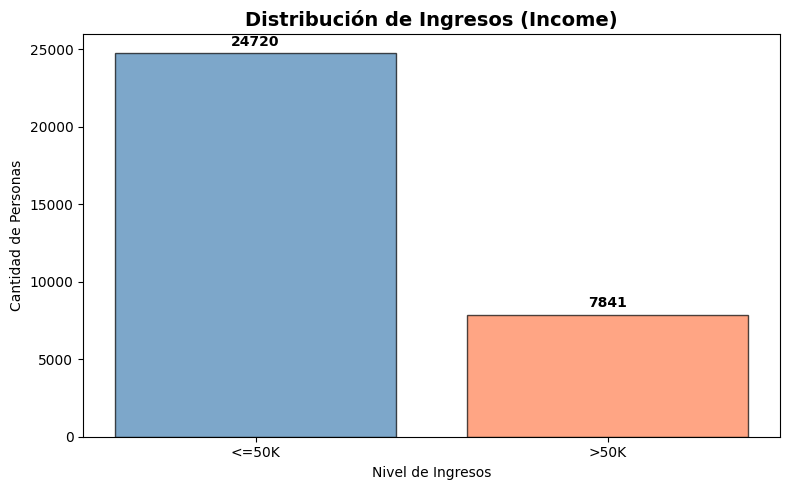


Balance del dataset:
<=50K: 24720 (75.9%)
>50K: 7841 (24.1%)


In [7]:
# Distribución del target
target_counts = df['income'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(target_counts.index, target_counts.values, color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
plt.title('Distribución de Ingresos (Income)', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Personas')
plt.xlabel('Nivel de Ingresos')

# Agregar valores sobre las barras
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nBalance del dataset:")
print(f"<=50K: {target_counts.iloc[0]} ({target_counts.iloc[0]/len(df)*100:.1f}%)")
print(f">50K: {target_counts.iloc[1]} ({target_counts.iloc[1]/len(df)*100:.1f}%)")

---
# LIMPIEZA DE DATOS

## Tratamiento de Valores Faltantes

In [8]:
# Eliminar filas con valores faltantes (son pocos)
print(f"Filas antes de eliminar NaN: {len(df)}")
df_clean = df.dropna()
print(f"Filas después de eliminar NaN: {len(df_clean)}")
print(f"Filas eliminadas: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

Filas antes de eliminar NaN: 32561
Filas después de eliminar NaN: 30162
Filas eliminadas: 2399 (7.4%)


## Tratamiento de Outliers

In [9]:
# Estadísticas de variables numéricas
numeric_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
df_clean[numeric_cols].describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,30162.000000,3.016200e+04,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1.897938e+05,10.121312,1092.007858,88.372489,40.931238
std,13.134665,1.056530e+05,2.549995,7406.346497,404.298370,11.979984
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176272e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784250e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376285e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
# Verificar valores extremos
print("Edad mínima:", df_clean['age'].min())
print("Edad máxima:", df_clean['age'].max())
print("\nHoras por semana mínimas:", df_clean['hours_per_week'].min())
print("Horas por semana máximas:", df_clean['hours_per_week'].max())

print("\n✅ No se detectan outliers problemáticos")

Edad mínima: 17
Edad máxima: 90

Horas por semana mínimas: 1
Horas por semana máximas: 99

✅ No se detectan outliers problemáticos


---
# PREPROCESAMIENTO

## Encoding de Variables Categóricas

In [11]:
# Identificar variables categóricas (excepto el target)
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('income')  # Excluir target

print(f"Variables categóricas: {categorical_cols}")

# One-Hot Encoding manual
df_encoded = df_clean.copy()

for col in categorical_cols:
    dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)
    df_encoded.drop(col, axis=1, inplace=True)

print(f"\n✅ Encoding completado")
print(f"Shape después de encoding: {df_encoded.shape}")

Variables categóricas: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

✅ Encoding completado
Shape después de encoding: (30162, 97)


## Codificar Target

In [12]:
# Convertir target a binario (0 = <=50K, 1 = >50K)
df_encoded['income'] = (df_encoded['income'] == '>50K').astype(int)

print("✅ Target codificado")
print(f"\nDistribución:")
print(df_encoded['income'].value_counts())

✅ Target codificado

Distribución:
income
0    22654
1     7508
Name: count, dtype: int64


## Separar Features y Target

In [13]:
# Target
y = df_encoded['income'].values

# Features (todas excepto el target)
# fnlwgt no es un feature predictivo (peso estadístico), lo eliminamos
X = df_encoded.drop(['income', 'fnlwgt'], axis=1).values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nNombre de features (primeras 10):")
print(df_encoded.drop(['income', 'fnlwgt'], axis=1).columns.tolist()[:10])

X shape: (30162, 95)
y shape: (30162,)

Nombre de features (primeras 10):
['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov']


## Train-Test Split Manual (80-20)

In [14]:
# Configuración
np.random.seed(42)
test_size = 0.2

# Generar índices aleatorios
n_samples = len(X)
indices = np.random.permutation(n_samples)

# Calcular punto de corte
test_size_abs = int(n_samples * test_size)
train_size_abs = n_samples - test_size_abs

# Dividir índices
train_indices = indices[:train_size_abs]
test_indices = indices[train_size_abs:]

# Crear conjuntos
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print(f"✅ Split completado")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"\nDistribución target en Train: {np.bincount(y_train)}")
print(f"Distribución target en Test: {np.bincount(y_test)}")

✅ Split completado
Train: 24130 muestras
Test: 6032 muestras

Distribución target en Train: [18144  5986]
Distribución target en Test: [4510 1522]


## Escalado Manual (StandardScaler)

Fórmula: `x_scaled = (x - mean) / std`

**IMPORTANTE**: Calcular media y desviación estándar SOLO con datos de entrenamiento para evitar data leakage.

In [15]:
# Calcular media y desviación estándar del TRAIN set
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Evitar división por cero (columnas constantes)
std_train[std_train == 0] = 1

# Aplicar escalado
X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train  # Usar estadísticas del train

# Convertir a float explícitamente
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

print("✅ Escalado completado")
print(f"\nMedia de X_train_scaled (primeras 5 features): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Desv. Std de X_train_scaled (primeras 5 features): {X_train_scaled.std(axis=0)[:5]}")

TypeError: loop of ufunc does not support argument 0 of type float which has no callable sqrt method

---
# VALIDACIÓN FINAL

## 1. Verificar Data Leakage

In [ ]:
# Verificar que no hay índices compartidos entre train y test
shared_indices = np.intersect1d(train_indices, test_indices)

if len(shared_indices) == 0:
    print("✅ No hay data leakage (índices únicos en train y test)")
else:
    print(f"⚠️ ALERTA: {len(shared_indices)} índices compartidos detectados")

## 2. Verificar NaN e Infinitos

In [ ]:
# Verificar NaN
nan_train = np.isnan(X_train_scaled).sum()
nan_test = np.isnan(X_test_scaled).sum()

# Verificar infinitos
inf_train = np.isinf(X_train_scaled).sum()
inf_test = np.isinf(X_test_scaled).sum()

print(f"NaN en X_train_scaled: {nan_train}")
print(f"NaN en X_test_scaled: {nan_test}")
print(f"Infinitos en X_train_scaled: {inf_train}")
print(f"Infinitos en X_test_scaled: {inf_test}")

if nan_train == 0 and nan_test == 0 and inf_train == 0 and inf_test == 0:
    print("\n✅ Datos limpios (sin NaN ni infinitos)")
else:
    print("\n⚠️ ALERTA: Hay NaN o infinitos en los datos")

## 3. Comparar Distribuciones Train vs Test

In [ ]:
# Comparar media y std de las primeras 5 features
print("=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===")
print("\nMEDIA:")
print(f"Train: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.mean(axis=0)[:5]}")

print("\nDESVIACIÓN ESTÁNDAR:")
print(f"Train: {X_train_scaled.std(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.std(axis=0)[:5]}")

print("\n✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)")

## Resumen Final

In [ ]:
print("="*60)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*60)
print(f"Dataset original: {df.shape}")
print(f"Dataset después de limpieza: {df_clean.shape}")
print(f"Features después de encoding: {X.shape[1]}")
print(f"Train set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"\nTarget (ingresos):")
print(f"  - Clase 0 (<=50K): {(y==0).sum()} casos")
print(f"  - Clase 1 (>50K): {(y==1).sum()} casos")
print(f"\n✅ Datos listos para entrenamiento de modelos de clasificación")
print("="*60)